# Aula 03 - Persistência de Arquivos: Propriedades e Dados Estruturados, Semiestruturados e Não Estruturados
**QXD0099 - Desenvolvimento de Software para Persistência**  
Universidade Federal do Ceará - Campus Quixadá  
Prof. Francisco Victor da Silva Pinheiro  
victorpinheiro@ufc.br

## Agenda
- Arquivos de propriedades
- Arquivamento de vários arquivos
- Dados estruturados
- Dados semiestruturados
- Dados não estruturados
- Scraping Tools
- Extração de websites
- Extração a partir de PDF
- GED — Gestão Eletrônica de Documentos
- Extração de dados de imagens
- Extração de JSON
- Extração de XML

# 1. Arquivos de propriedades

Arquivos de propriedades são usados para persistir configurações da aplicação.

Em Python, um `dict` representa naturalmente pares **chave → valor**.

In [ ]:
config = {
    "database.login": "scott",
    "database.password": "tiger",
    "database.url": "jdbc:mysql://localhost/teste"
}

login = config.get("database.login")
password = config.get("database.password")
url = config.get("database.url")

print("Login:", login)
print("Password:", password)
print("URL:", url)

Login: scott
Password: tiger
URL: jdbc:mysql://localhost/teste


## 2. Gravando propriedades com `configparser`

In [ ]:
import configparser

config = configparser.ConfigParser()

config["DEFAULT"] = {
    "database": "localhost",
    "dbuser": "mkyong",
    "dbpassword": "password"
}

with open("config.ini", "w", encoding="utf-8") as configfile:
    config.write(configfile)

print("config.ini criado.")

config.ini criado.


In [ ]:
with open("config.ini", "r", encoding="utf-8") as arquivo:
    print(arquivo.read())

[DEFAULT]
database = localhost
dbuser = mkyong
dbpassword = password




## 3. Lendo propriedades

In [ ]:
import configparser

config = configparser.ConfigParser()
config.read("config.ini", encoding="utf-8")

database = config["DEFAULT"].get("database")
dbuser = config["DEFAULT"].get("dbuser")
dbpassword = config["DEFAULT"].get("dbpassword")

print(f"Database: {database}")
print(f"DB User: {dbuser}")
print(f"DB Password: {dbpassword}")

Database: localhost
DB User: mkyong
DB Password: password


# 4. Arquivamento de vários arquivos

Arquivar significa reunir vários arquivos em um único contêiner. Um exemplo clássico é o formato TAR.

In [ ]:
for i in range(1, 4):
    with open(f"documento{i}.txt", "w", encoding="utf-8") as arquivo:
        arquivo.write(f"Conteúdo do documento {i}\n")

print("Arquivos criados.")

Arquivos criados.


In [ ]:
!tar -cvf documentos.tar documento1.txt documento2.txt documento3.txt

documento1.txt
documento2.txt
documento3.txt


In [ ]:
!tar -tvf documentos.tar

-rw-r--r-- root/root        25 2026-08-21 00:24 documento1.txt
-rw-r--r-- root/root        25 2026-08-21 00:24 documento2.txt
-rw-r--r-- root/root        25 2026-08-21 00:24 documento3.txt


### Arquivamento com Python

In [ ]:
import tarfile

with tarfile.open("documentos_python.tar", "w") as tar:
    tar.add("documento1.txt")
    tar.add("documento2.txt")
    tar.add("documento3.txt")

print("Arquivo TAR criado.")

Arquivo TAR criado.


# 5. Dados estruturados, semiestruturados e não estruturados

A organização dos dados influencia armazenamento, validação, consulta e extração.

## 6. Dados estruturados

Possuem formato rígido ou esquema bem definido.

| ID_Cliente | Nome | E-mail | Telefone | Data_Cadastro |
|---|---|---|---|---|
| 1 | João Silva | joao.silva@gmail.com | (11) 91234-5678 | 2023-01-10 |
| 2 | Maria Oliveira | maria.oliveira@gmail.com | (21) 98765-4321 | 2023-02-15 |

In [ ]:
clientes = [
    {
        "ID_Cliente": 1,
        "Nome": "João Silva",
        "Email": "joao.silva@gmail.com",
        "Telefone": "(11) 91234-5678",
        "Data_Cadastro": "2023-01-10"
    },
    {
        "ID_Cliente": 2,
        "Nome": "Maria Oliveira",
        "Email": "maria.oliveira@gmail.com",
        "Telefone": "(21) 98765-4321",
        "Data_Cadastro": "2023-02-15"
    }
]

for cliente in clientes:
    print(cliente)

{'ID_Cliente': 1, 'Nome': 'João Silva', 'Email': 'joao.silva@gmail.com', 'Telefone': '(11) 91234-5678', 'Data_Cadastro': '2023-01-10'}
{'ID_Cliente': 2, 'Nome': 'Maria Oliveira', 'Email': 'maria.oliveira@gmail.com', 'Telefone': '(21) 98765-4321', 'Data_Cadastro': '2023-02-15'}


## 7. Dados semiestruturados

Possuem organização, mas não exigem que todos os objetos tenham exatamente os mesmos atributos.

Exemplos: JSON e XML.

In [ ]:
clientes_semiestruturados = [
    {
        "id_cliente": 1,
        "nome": "João Silva",
        "email": "joao.silva@email.com",
        "pedidos": [
            {
                "id_pedido": 101,
                "data_pedido": "2023-01-12",
                "valor_total": 200.00,
                "status": "Entregue"
            }
        ]
    },
    {
        "id_cliente": 2,
        "nome": "Maria Oliveira",
        "email": "maria.oliveira@email.com",
        "telefone": "(85) 99999-9999",
        "pedidos": [
            {
                "id_pedido": 102,
                "data_pedido": "2023-02-20",
                "valor_total": 350.00,
                "status": "Em processamento"
            }
        ]
    }
]

for cliente in clientes_semiestruturados:
    print(cliente)

{'id_cliente': 1, 'nome': 'João Silva', 'email': 'joao.silva@email.com', 'pedidos': [{'id_pedido': 101, 'data_pedido': '2023-01-12', 'valor_total': 200.0, 'status': 'Entregue'}]}
{'id_cliente': 2, 'nome': 'Maria Oliveira', 'email': 'maria.oliveira@email.com', 'telefone': '(85) 99999-9999', 'pedidos': [{'id_pedido': 102, 'data_pedido': '2023-02-20', 'valor_total': 350.0, 'status': 'Em processamento'}]}


## 8. Dados não estruturados

Não seguem um esquema tabular rígido.

Exemplos: texto livre, e-mail, mensagens, HTML, PDF, imagem, áudio e vídeo.

In [ ]:
texto_livre = """
Hoje foi um dia incrível!
Visitei o parque com meus amigos e tiramos muitas fotos.
O pôr do sol estava lindo!
#Natureza #Amigos #Felicidade
"""

print(texto_livre)


Hoje foi um dia incrível!
Visitei o parque com meus amigos e tiramos muitas fotos.
O pôr do sol estava lindo!
#Natureza #Amigos #Felicidade



In [ ]:
email = """
De: maria.oliveira@email.com
Para: joao.silva@email.com
Assunto: Reunião de Projeto

Oi João,

Gostaria de confirmar nossa reunião de projeto para amanhã às 10h.

Abraços,
Maria
"""

print(email)


De: maria.oliveira@email.com
Para: joao.silva@email.com
Assunto: Reunião de Projeto

Oi João,

Gostaria de confirmar nossa reunião de projeto para amanhã às 10h.

Abraços,
Maria



# 9. Comparação

| Tipo | Característica | Exemplos |
|---|---|---|
| Estruturado | Esquema rígido | tabela relacional |
| Semiestruturado | Estrutura flexível/autodescritiva | JSON, XML |
| Não estruturado | Estrutura limitada ou voltada à apresentação | texto, HTML, PDF, imagem |

# 10. Scraping Tools — Web

`BeautifulSoup` permite extrair e navegar por HTML e XML. `requests` permite obter páginas Web.

In [ ]:
!pip -q install beautifulsoup4 requests lxml

## 11. Criando uma página HTML local

In [ ]:
html = """
<!DOCTYPE html>
<html>
<head>
    <title>Portal da Disciplina</title>
</head>
<body>
    <div class="masthead">
        <h1>QXD0099</h1>
    </div>

    <h2>Materiais</h2>

    <a href="aula1.html">Aula 1</a>
    <a href="aula2.html">Aula 2</a>

    <img src="logo.png">
    <img src="foto.jpg">

    <div class="resultado">
        <h3 class="r">
            <a href="https://example.com/material">Material complementar</a>
        </h3>
    </div>
</body>
</html>
"""

with open("input.html", "w", encoding="utf-8") as arquivo:
    arquivo.write(html)

print("input.html criado.")

input.html criado.


## 12. Lendo HTML com BeautifulSoup

In [ ]:
from bs4 import BeautifulSoup

with open("input.html", "r", encoding="utf-8") as arquivo:
    doc = BeautifulSoup(arquivo, "html.parser")

print("Título:", doc.title.string)

Título: Portal da Disciplina


## 13. Selecionando links

In [ ]:
links = doc.select("a[href]")

for link in links:
    print("Texto:", link.text.strip())
    print("URL:", link.get("href"))
    print("---")

Texto: Aula 1
URL: aula1.html
---
Texto: Aula 2
URL: aula2.html
---
Texto: Material complementar
URL: https://example.com/material
---


## 14. Selecionando imagens PNG

In [ ]:
pngs = doc.select("img[src$='.png']")

for imagem in pngs:
    print(imagem.get("src"))

logo.png


## 15. Selecionando um elemento específico

In [ ]:
masthead = doc.select_one("div.masthead")

print(masthead.text.strip())

QXD0099


## 16. Links de resultados

In [ ]:
result_links = doc.select("h3.r > a")

for link in result_links:
    print(link.text.strip(), "->", link.get("href"))

Material complementar -> https://example.com/material


# 17. Extração de website com `requests`

O exemplo depende de acesso à internet.

In [ ]:
import requests
from bs4 import BeautifulSoup

url = "https://quotes.toscrape.com/"

try:
    response = requests.get(url, timeout=10)
    response.raise_for_status()

    doc_web = BeautifulSoup(
        response.content,
        "html.parser"
    )

    print("Título:", doc_web.title.string)

except requests.RequestException as erro:
    print("Não foi possível acessar o site.")
    print(erro)

Título: Quotes to Scrape


# 18. Scraping Tools — PDF

Bibliotecas da aula:

- `tabula-py`
- `PyPDF2`
- `pdfplumber`
- `pdfminer.six`

In [ ]:
!pip -q install reportlab PyPDF2 pdfplumber pdfminer.six

## 19. Criando um PDF textual de exemplo

In [ ]:
from reportlab.pdfgen import canvas

pdf = canvas.Canvas("example.pdf")

pdf.drawString(72, 800, "Relatorio de Persistencia")
pdf.drawString(72, 780, "Disciplina: QXD0099")
pdf.drawString(72, 760, "Professor: Victor Pinheiro")
pdf.drawString(72, 740, "Conteudo: arquivos, persistencia e extracao de dados.")

pdf.save()

print("example.pdf criado.")

example.pdf criado.


## 20. PyPDF2

In [ ]:
from PyPDF2 import PdfReader

reader = PdfReader("example.pdf")

for numero, page in enumerate(reader.pages, start=1):
    print(f"--- Página {numero} ---")
    print(page.extract_text())

--- Página 1 ---
Relatorio de Persistencia
Disciplina: QXD0099
Professor: Victor Pinheiro
Conteudo: arquivos, persistencia e extracao de dados.



## 21. pdfplumber

In [ ]:
import pdfplumber

with pdfplumber.open("example.pdf") as pdf:
    for numero, page in enumerate(pdf.pages, start=1):
        print(f"--- Página {numero} ---")
        print(page.extract_text())

--- Página 1 ---
Relatorio de Persistencia
Disciplina: QXD0099
Professor: Victor Pinheiro
Conteudo: arquivos, persistencia e extracao de dados.


## 22. pdfminer.six

In [ ]:
from pdfminer.high_level import extract_text

text = extract_text("example.pdf")
print(text)

Relatorio de Persistencia

Disciplina: QXD0099

Professor: Victor Pinheiro

Conteudo: arquivos, persistencia e extracao de dados.




## 23. Comparação rápida das bibliotecas

- **Tabula-py**: tabelas.
- **PyPDF2**: tarefas básicas e texto simples.
- **pdfplumber**: texto e tabelas.
- **pdfminer.six**: maior controle sobre texto e layout.

## 24. Tabula-py

In [ ]:
!pip -q install tabula-py
!pip install -q jpype1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 2.8 MB/s eta 0:00:00


In [ ]:
from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.platypus import (
    SimpleDocTemplate,
    Table,
    TableStyle,
    Paragraph,
    Spacer
)
from reportlab.lib.styles import getSampleStyleSheet

arquivo_pdf = "relatorio_tabela.pdf"

doc = SimpleDocTemplate(
    arquivo_pdf,
    pagesize=A4
)

styles = getSampleStyleSheet()

elementos = []

titulo = Paragraph(
    "Relatório de Alunos - QXD0099",
    styles["Title"]
)

elementos.append(titulo)
elementos.append(Spacer(1, 20))

dados = [
    ["Aluno", "Nota", "Frequência"],
    ["Ana", "8.5", "90"],
    ["Bruno", "6.0", "75"],
    ["Carla", "9.2", "95"],
    ["Daniel", "7.0", "80"]
]

tabela = Table(dados)

tabela.setStyle(
    TableStyle([
        ("GRID", (0, 0), (-1, -1), 1, colors.black),
        ("ALIGN", (0, 0), (-1, -1), "CENTER"),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("BOTTOMPADDING", (0, 0), (-1, 0), 8),
    ])
)

elementos.append(tabela)

doc.build(elementos)

print("PDF com tabela criado:", arquivo_pdf)

PDF com tabela criado: relatorio_tabela.pdf


In [ ]:
import tabula

try:
    tables = tabula.read_pdf(
        "relatorio_tabela.pdf",
        pages="all",
        multiple_tables=True
    )

    print("Quantidade de tabelas:", len(tables))

    for i, table in enumerate(tables, start=1):
        print(f"\nTabela {i}:")
        display(table)

except Exception as erro:
    print("Não foi possível extrair tabelas.")
    print(type(erro).__name__)
    print(erro)

Quantidade de tabelas: 1

Tabela 1:


,Aluno,Nota,Frequência
0,Ana,8.5,90
1,Bruno,6.0,75
2,Carla,9.2,95
3,Daniel,7.0,80


### Conversão direta PDF → CSV

Quando o PDF possui tabela detectável:

```python
tabula.convert_into(
    "Relatorio_anual_dados.pdf",
    "output.csv",
    output_format="csv",
    pages="all"
)
```

# 25. GED — Gestão Eletrônica de Documentos

OCR permite transformar texto presente em imagens em texto manipulável.

## 26. Instalando Tesseract no Colab

In [ ]:
!apt-get -qq update
!apt-get -qq install -y tesseract-ocr
!pip -q install pytesseract pillow

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


## 27. Criando uma imagem com texto

In [ ]:
!pip uninstall -y pillow
!pip install --no-cache-dir --force-reinstall pillow
!pip install -q --upgrade --force-reinstall pillow pytesseract

Found existing installation: pillow 12.3.0
Uninstalling pillow-12.3.0:
  Successfully uninstalled pillow-12.3.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 738.1 kB/s eta 0:00:00


In [ ]:
from PIL import Image, ImageDraw

image = Image.new(
    "RGB",
    (900, 250),
    "white"
)

draw = ImageDraw.Draw(image)

draw.text(
    (40, 60),
    "Persistencia de Arquivos - QXD0099",
    fill="black"
)

draw.text(
    (40, 120),
    "Universidade Federal do Ceara",
    fill="black"
)

image.save("document_image.png")

print("document_image.png criado.")

document_image.png criado.


## 28. Visualizando a imagem

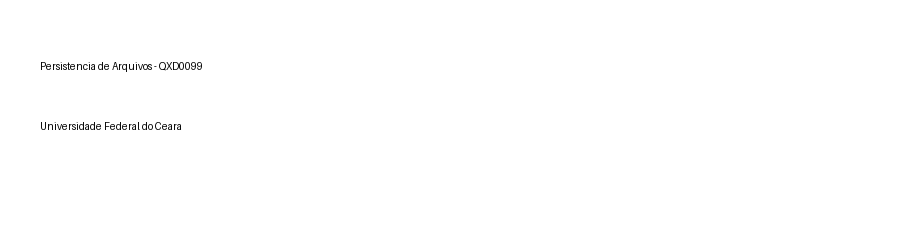

In [ ]:
from IPython.display import display
from PIL import Image

display(Image.open("document_image.png"))

## 29. Extraindo texto com Tesseract

In [ ]:
import pytesseract
from PIL import Image

image = Image.open("document_image.png")

text = pytesseract.image_to_string(image)

print("Texto extraído:")
print(text)

Texto extraído:
Persistencia de Arquives-QXDO089

Universidade Federal doCeara



## 30. Aplicações comuns em GED

- digitalização de documentos;
- indexação;
- busca;
- automação;
- extração de texto de documentos escaneados.

# 31. Extração de JSON

JSON é um formato semiestruturado muito usado em APIs, configurações e integração entre sistemas.

In [ ]:
import json

dados_json = {
    "chave_principal": "Persistência",
    "disciplina": "QXD0099",
    "alunos": [
        {"nome": "Ana", "nota": 8.5},
        {"nome": "Bruno", "nota": 7.0}
    ]
}

with open("dados.json", "w", encoding="utf-8") as arquivo:
    json.dump(
        dados_json,
        arquivo,
        ensure_ascii=False,
        indent=4
    )

print("dados.json criado.")

dados.json criado.


## 32. Lendo JSON

In [ ]:
import json

with open("dados.json", "r", encoding="utf-8") as arquivo:
    data = json.load(arquivo)

print(data["chave_principal"])

for aluno in data["alunos"]:
    print(aluno["nome"], "-", aluno["nota"])

Persistência
Ana - 8.5
Bruno - 7.0


# 33. Extração de XML

XML possui organização hierárquica baseada em tags.

In [ ]:
xml = """<?xml version="1.0" encoding="UTF-8"?>
<clientes>
    <cliente>
        <nome>João Silva</nome>
        <email>joao@email.com</email>
        <telefone>85999990000</telefone>
        <compras>
            <compra>
                <id_compra>101</id_compra>
                <data>2026-08-01</data>
                <total>250.00</total>
                <itens>
                    <item>
                        <produto>Teclado</produto>
                        <quantidade>1</quantidade>
                        <preco_unitario>250.00</preco_unitario>
                    </item>
                </itens>
            </compra>
        </compras>
    </cliente>

    <cliente>
        <nome>Maria Oliveira</nome>
        <email>maria@email.com</email>
        <telefone>85988880000</telefone>
        <compras>
            <compra>
                <id_compra>102</id_compra>
                <data>2026-08-10</data>
                <total>120.00</total>
                <itens>
                    <item>
                        <produto>Mouse</produto>
                        <quantidade>2</quantidade>
                        <preco_unitario>60.00</preco_unitario>
                    </item>
                </itens>
            </compra>
        </compras>
    </cliente>
</clientes>
"""

with open("dados.xml", "w", encoding="utf-8") as arquivo:
    arquivo.write(xml)

print("dados.xml criado.")

dados.xml criado.


## 34. Parse com ElementTree

In [ ]:
import xml.etree.ElementTree as ET

tree = ET.parse("dados.xml")
root = tree.getroot()

print("Elemento raiz:", root.tag)

Elemento raiz: clientes


## 35. Extraindo clientes

In [ ]:
for cliente in root.findall("cliente"):
    nome = cliente.find("nome").text
    email = cliente.find("email").text
    telefone = cliente.find("telefone").text

    print(
        f"Nome: {nome}, "
        f"Email: {email}, "
        f"Telefone: {telefone}"
    )

Nome: João Silva, Email: joao@email.com, Telefone: 85999990000
Nome: Maria Oliveira, Email: maria@email.com, Telefone: 85988880000


## 36. Navegando por compras e itens

In [ ]:
for cliente in root.findall("cliente"):

    nome = cliente.find("nome").text
    print(f"\nCLIENTE: {nome}")

    for compra in cliente.find("compras").findall("compra"):

        id_compra = compra.find("id_compra").text
        data = compra.find("data").text
        total = compra.find("total").text

        print(
            f" Compra ID: {id_compra}, "
            f"Data: {data}, "
            f"Total: {total}"
        )

        for item in compra.find("itens").findall("item"):

            produto = item.find("produto").text
            quantidade = item.find("quantidade").text
            preco = item.find("preco_unitario").text

            print(
                f"   Produto: {produto}, "
                f"Quantidade: {quantidade}, "
                f"Preço Unitário: {preco}"
            )


CLIENTE: João Silva
 Compra ID: 101, Data: 2026-08-01, Total: 250.00
   Produto: Teclado, Quantidade: 1, Preço Unitário: 250.00

CLIENTE: Maria Oliveira
 Compra ID: 102, Data: 2026-08-10, Total: 120.00
   Produto: Mouse, Quantidade: 2, Preço Unitário: 60.00


## 37. XML com BeautifulSoup + lxml

In [ ]:
from bs4 import BeautifulSoup

with open("dados.xml", "r", encoding="utf-8") as arquivo:
    soup = BeautifulSoup(arquivo, "xml")

for cliente in soup.find_all("cliente"):
    nome = cliente.find("nome").text
    email = cliente.find("email").text
    print(nome, "-", email)

João Silva - joao@email.com
Maria Oliveira - maria@email.com


# 38. Mini laboratório — HTML → JSON

Vamos extrair links de HTML e persistir o resultado em JSON.

In [ ]:
from bs4 import BeautifulSoup
import json

with open("input.html", "r", encoding="utf-8") as arquivo:
    soup_html = BeautifulSoup(arquivo, "html.parser")

links_extraidos = []

for link in soup_html.select("a[href]"):
    links_extraidos.append({
        "texto": link.text.strip(),
        "url": link.get("href")
    })

print(links_extraidos)

[{'texto': 'Aula 1', 'url': 'aula1.html'}, {'texto': 'Aula 2', 'url': 'aula2.html'}, {'texto': 'Material complementar', 'url': 'https://example.com/material'}]


In [ ]:
with open("links_extraidos.json", "w", encoding="utf-8") as arquivo:
    json.dump(
        links_extraidos,
        arquivo,
        ensure_ascii=False,
        indent=4
    )

print("links_extraidos.json criado.")

links_extraidos.json criado.


# 39. Mini laboratório — XML → lista de dicionários

In [ ]:
import xml.etree.ElementTree as ET

tree = ET.parse("dados.xml")
root = tree.getroot()

clientes_python = []

for cliente in root.findall("cliente"):
    clientes_python.append({
        "nome": cliente.find("nome").text,
        "email": cliente.find("email").text,
        "telefone": cliente.find("telefone").text
    })

clientes_python

[{'nome': 'João Silva', 'email': 'joao@email.com', 'telefone': '85999990000'},
 {'nome': 'Maria Oliveira',
  'email': 'maria@email.com',
  'telefone': '85988880000'}]

# 40. Atividade 2 — Extrator de HTML

Leia `input.html` e extraia:
- título;
- links;
- imagens.

Salve em `resultado_scraping.json`.

In [ ]:
# SOLUÇÃO DE REFERÊNCIA

from bs4 import BeautifulSoup
import json

with open("input.html", "r", encoding="utf-8") as arquivo:
    soup = BeautifulSoup(arquivo, "html.parser")

resultado = {
    "titulo": soup.title.string if soup.title else None,
    "links": [
        {
            "texto": link.text.strip(),
            "href": link.get("href")
        }
        for link in soup.select("a[href]")
    ],
    "imagens": [
        imagem.get("src")
        for imagem in soup.select("img[src]")
    ]
}

with open(
    "resultado_scraping.json",
    "w",
    encoding="utf-8"
) as arquivo:
    json.dump(
        resultado,
        arquivo,
        ensure_ascii=False,
        indent=4
    )

print(json.dumps(
    resultado,
    ensure_ascii=False,
    indent=4
))

{
    "titulo": "Portal da Disciplina",
    "links": [
        {
            "texto": "Aula 1",
            "href": "aula1.html"
        },
        {
            "texto": "Aula 2",
            "href": "aula2.html"
        },
        {
            "texto": "Material complementar",
            "href": "https://example.com/material"
        }
    ],
    "imagens": [
        "logo.png",
        "foto.jpg"
    ]
}


# Pontos principais

- arquivos de propriedades persistem configurações;
- dados estruturados seguem um esquema rígido;
- dados semiestruturados permitem estruturas flexíveis e aninhadas;
- dados não estruturados exigem técnicas específicas de extração;
- BeautifulSoup permite navegar por HTML e XML;
- `requests` permite obter páginas Web;
- PyPDF2, pdfplumber, pdfminer e Tabula atendem necessidades diferentes em PDFs;
- OCR permite extrair texto de imagens;
- JSON e XML permitem representar estruturas hierárquicas;
- dados extraídos podem ser transformados e novamente persistidos.